In [ ]:
import numpy as np
import random
import csv
import math
import matplotlib.pyplot as plt
import time

# --- Paramètres de la simulation ---
# Grille et Population
TAILLE_GRILLE = 300
NB_INDIVIDUS = 20000
DUREE_SIMULATION = 730

# Paramètres épidémiologiques
BETA = 0.5  # Force de l'infection
# Moyennes pour les durées (loi exponentielle)
MOY_DE = 3.0
MOY_DI = 7.0
MOY_DR = 365.0

# États possibles (pour plus de clarté)
S = 0
E = 1
I = 2
R = 3

class Individu:
    def __init__(self, id_agent):
        self.id = id_agent
        self.x = random.randint(0, TAILLE_GRILLE - 1)
        self.y = random.randint(0, TAILLE_GRILLE - 1)

        # État initial : Sauf pour quelques uns qui seront I
        self.statut = S
        self.temps_dans_etat = 0

        # Tirage des durées personnelles (une fois pour toutes au début)
        # Formule : -moyenne * log(1 - random)
        self.duree_E = -MOY_DE * math.log(1.0 - random.random())
        self.duree_I = -MOY_DI * math.log(1.0 - random.random())
        self.duree_R = -MOY_DR * math.log(1.0 - random.random())

def simulation_multi_agent_python():
    print("Démarrage de la simulation Multi-Agent (Python)...")
    start_time = time.time()

    # 1. Initialisation de la population
    population = []
    for k in range(NB_INDIVIDUS):
        agent = Individu(k)
        population.append(agent)

    # On infecte 20 individus au hasard
    indices_infectes = random.sample(range(NB_INDIVIDUS), 20)
    for idx in indices_infectes:
        population[idx].statut = I

    # Fichier de sortie
    fichier_csv = open("resultats_sma_python.csv", "w", newline="")
    writer = csv.writer(fichier_csv)
    writer.writerow(["jour", "S", "E", "I", "R"])

    # Boucle temporelle (Jours)
    for jour in range(DUREE_SIMULATION):

        # A. Déplacement aléatoire de tout le monde
        # On crée une grille pour repérer qui est où (pour l'infection)
        grille = {} # Dictionnaire (x,y) -> liste des agents présents

        for agent in population:
            # Nouvelle position au hasard
            agent.x = random.randint(0, TAILLE_GRILLE - 1)
            agent.y = random.randint(0, TAILLE_GRILLE - 1)

            # On note sa présence sur la grille
            cle = (agent.x, agent.y)
            if cle not in grille:
                grille[cle] = []
            grille[cle].append(agent)

        # B. Gestion de l'infection et des changements d'états
        # On compte les statuts pour le CSV
        nb_S, nb_E, nb_I, nb_R = 0, 0, 0, 0

        # On mélange l'ordre de mise à jour (asynchrone aléatoire)
        random.shuffle(population)

        for agent in population:

            # --- Logique d'Infection (S -> E) ---
            if agent.statut == S:
                # On compte les infectés dans le voisinage (Moore : 8 cases + centre)
                nb_infectes_voisins = 0

                # On regarde les cases autour (dx, dy de -1 à +1)
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        # Gestion du tore (périodicité)
                        vx = (agent.x + dx) % TAILLE_GRILLE
                        vy = (agent.y + dy) % TAILLE_GRILLE

                        if (vx, vy) in grille:
                            # On regarde les agents sur cette case voisine
                            for voisin in grille[(vx, vy)]:
                                if voisin.statut == I:
                                    nb_infectes_voisins += 1

                # Calcul de la probabilité si contact avec infectés
                if nb_infectes_voisins > 0:
                    proba_infection = 1.0 - math.exp(-0.5 * nb_infectes_voisins)
                    if random.random() < proba_infection:
                        agent.statut = E
                        agent.temps_dans_etat = 0

            # --- Logique des transitions (E->I, I->R, R->S) ---
            elif agent.statut == E:
                if agent.temps_dans_etat > agent.duree_E:
                    agent.statut = I
                    agent.temps_dans_etat = 0

            elif agent.statut == I:
                if agent.temps_dans_etat > agent.duree_I:
                    agent.statut = R
                    agent.temps_dans_etat = 0

            elif agent.statut == R:
                if agent.temps_dans_etat > agent.duree_R:
                    agent.statut = S
                    agent.temps_dans_etat = 0

            # On met à jour le temps passé dans l'état actuel
            agent.temps_dans_etat += 1

            # Comptage final pour le jour courant
            if agent.statut == S: nb_S += 1
            elif agent.statut == E: nb_E += 1
            elif agent.statut == I: nb_I += 1
            elif agent.statut == R: nb_R += 1

        # Écriture dans le fichier CSV
        writer.writerow([jour, nb_S, nb_E, nb_I, nb_R])

        # Petit affichage tous les 50 jours pour voir si ça avance
        if jour % 50 == 0:
            print(f"Jour {jour}: S={nb_S}, I={nb_I}, R={nb_R}")

    fichier_csv.close()
    duree = time.time() - start_time
    print(f"Simulation terminée en {duree:.2f} secondes.")

# Lancer la simulation (ATTENTION : ça peut prendre quelques minutes en Python !)
simulation_multi_agent_python()


Démarrage de la simulation Multi-Agent (Python)...
Jour 0: S=19965, I=20, R=0
Jour 50: S=599, I=1177, R=18114
Jour 100: S=3174, I=18, R=16797
Jour 150: S=5195, I=82, R=14674
Jour 200: S=4349, I=696, R=14535
Jour 250: S=2987, I=536, R=16253
Jour 300: S=4114, I=592, R=14982
Jour 350: S=3423, I=732, R=15493
Jour 400: S=3639, I=692, R=15365
Jour 450: S=3630, I=754, R=15259
Jour 500: S=3518, I=638, R=15502
Jour 550: S=3545, I=704, R=15367
Jour 600: S=3836, I=635, R=15207
Jour 650: S=3400, I=817, R=15400
Jour 700: S=3637, I=646, R=15427
Simulation terminée en 84.81 secondes.


In [ ]:
%%writefile sma_seirs.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <random>
#include <fstream>
#include <algorithm>
#include <iomanip>
#include <chrono>

using namespace std;

// --- Paramètres Globaux ---
const int TAILLE_GRILLE = 300;
const int NB_AGENTS = 20000;
const int DUREE = 730;
const double BETA = 0.5;

// Moyennes pour les lois exponentielles
const double MOY_DE = 3.0;
const double MOY_DI = 7.0;
const double MOY_DR = 365.0;

// États
enum Statut { S, E, I, R };

struct Agent {
    int id;
    int x, y;
    Statut statut;
    int temps_dans_etat;

    // Durées propres à chaque agent
    int dE, dI, dR;
};

// --- Générateur aléatoire global ---
// On utilise Mersenne Twister comme suggéré
mt19937 gen; // Sera initialisé dans le main

// Fonction utilitaire pour loi exponentielle
int tirage_exponentiel(double moyenne) {
    uniform_real_distribution<> dis(0.0, 1.0);
    double r = dis(gen);
    // Formule : -moy * ln(1 - u)
    // On convertit en int (arrondi) car le temps est discret (jours)
    return (int)round(-moyenne * log(1.0 - r));
}

int main(int argc, char* argv[]) {
    // Gestion de la graine aléatoire (pour la reproductibilité ou varier les réplications)
    // Si on passe un argument, c'est la graine. Sinon graine fixe.
    int graine = 42;
    if (argc > 1) graine = atoi(argv[1]);
    gen.seed(graine);

    cout << "Simulation SMA C++ (Graine: " << graine << ")" << endl;
    auto start = chrono::high_resolution_clock::now();

    // 1. Initialisation des agents
    vector<Agent> population(NB_AGENTS);

    // Distributions pour positions
    uniform_int_distribution<> pos_dist(0, TAILLE_GRILLE - 1);

    for(int i=0; i<NB_AGENTS; ++i) {
        population[i].id = i;
        population[i].x = pos_dist(gen);
        population[i].y = pos_dist(gen);
        population[i].statut = S;
        population[i].temps_dans_etat = 0;

        // Tirage des durées
        population[i].dE = tirage_exponentiel(MOY_DE);
        population[i].dI = tirage_exponentiel(MOY_DI);
        population[i].dR = tirage_exponentiel(MOY_DR);
    }

    // Infecter 20 agents au hasard
    // On mélange le vecteur d'indices ou on prend les 20 premiers après shuffle
    // Ici méthode simple : on force les 20 premiers (car ils ont été placés au hasard juste avant)
    for(int i=0; i<20; ++i) {
        population[i].statut = I;
    }

    // Fichier CSV de sortie
    string nom_fichier = "resultats_sma_cpp_" + to_string(graine) + ".csv";
    ofstream fichier(nom_fichier);
    fichier << "jour,S,E,I,R\n";

    // --- Boucle Principale (Jours) ---
    for(int jour=0; jour<DUREE; ++jour) {

        // A. Déplacement Aléatoire
        // Grille pour accès rapide : grille[x][y] contient la liste des indices des agents
        // On remet à zéro la grille à chaque tour
        // Utilisation d'un vecteur de vecteurs de vecteurs peut être lourd.
        // Optimisation : Tableau 1D de vecteurs
        static vector<int> grille[TAILLE_GRILLE * TAILLE_GRILLE];

        // Reset de la grille (vider les vecteurs sans réallouer)
        for(int k=0; k<TAILLE_GRILLE*TAILLE_GRILLE; ++k) grille[k].clear();

        for(auto& agent : population) {
            // Déplacement
            agent.x = pos_dist(gen);
            agent.y = pos_dist(gen);

            // Enregistrement sur la grille
            int index_grille = agent.x * TAILLE_GRILLE + agent.y;
            grille[index_grille].push_back(agent.id);
        }

        // B. Infection et Transitions
        // Mélange pour l'asynchronisme
        // Pour être vraiment "asynchrone aléatoire", on devrait mélanger l'ordre de mise à jour
        // Mais std::shuffle sur 20000 éléments à chaque tour est coûteux.
        // L'énoncé dit "L'ordre d'exécution est aléatoire". On peut le faire par indices.
        vector<int> ordre(NB_AGENTS);
        iota(ordre.begin(), ordre.end(), 0); // 0, 1, 2...
        shuffle(ordre.begin(), ordre.end(), gen);

        int nb_S=0, nb_E=0, nb_I=0, nb_R=0;

        uniform_real_distribution<> dis_proba(0.0, 1.0);

        for(int idx : ordre) {
            Agent& ag = population[idx];

            // --- INFECTION (S -> E) ---
            if(ag.statut == S) {
                int n_infectes = 0;

                // Voisinage de Moore (dx, dy dans {-1, 0, 1})
                for(int dx=-1; dx<=1; ++dx) {
                    for(int dy=-1; dy<=1; ++dy) {
                        // Gestion tore
                        int vx = (ag.x + dx + TAILLE_GRILLE) % TAILLE_GRILLE;
                        int vy = (ag.y + dy + TAILLE_GRILLE) % TAILLE_GRILLE;

                        int idx_voisin = vx * TAILLE_GRILLE + vy;

                        // On parcourt les agents sur cette case
                        for(int id_voisin : grille[idx_voisin]) {
                            if(population[id_voisin].statut == I) {
                                n_infectes++;
                            }
                        }
                    }
                }

                if(n_infectes > 0) {
                    double p = 1.0 - exp(-0.5 * n_infectes);
                    if(dis_proba(gen) < p) {
                        ag.statut = E;
                        ag.temps_dans_etat = 0;
                    }
                }
            }
            // --- Transitions ---
            else if(ag.statut == E) {
                if(ag.temps_dans_etat >= ag.dE) {
                    ag.statut = I;
                    ag.temps_dans_etat = 0;
                }
            }
            else if(ag.statut == I) {
                if(ag.temps_dans_etat >= ag.dI) {
                    ag.statut = R;
                    ag.temps_dans_etat = 0;
                }
            }
            else if(ag.statut == R) {
                if(ag.temps_dans_etat >= ag.dR) {
                    ag.statut = S;
                    ag.temps_dans_etat = 0;
                }
            }

            // Mise à jour compteur temps
            ag.temps_dans_etat++;

            // Compteurs pour stats
            if(ag.statut == S) nb_S++;
            else if(ag.statut == E) nb_E++;
            else if(ag.statut == I) nb_I++;
            else if(ag.statut == R) nb_R++;
        }

        fichier << jour << "," << nb_S << "," << nb_E << "," << nb_I << "," << nb_R << "\n";
    }

    fichier.close();
    auto end = chrono::high_resolution_clock::now();
    chrono::duration<double> diff = end-start;
    cout << "Termine en " << diff.count() << " s." << endl;

    return 0;
}


Writing sma_seirs.cpp


In [ ]:
!g++ -O3 sma_seirs.cpp -o sma_seirs
!./sma_seirs 1


Simulation SMA C++ (Graine: 1)
Termine en 2.37718 s.


In [ ]:
%%bash
# On lance 30 fois le programme C++ en changeant la graine (seed) de 1 à 30
for i in {1..30}
do
   ./sma_seirs $i
done

echo "Toutes les simulations sont finies !"



Simulation SMA C++ (Graine: 1)
Termine en 3.01205 s.
Simulation SMA C++ (Graine: 2)
Termine en 3.02223 s.
Simulation SMA C++ (Graine: 3)
Termine en 2.51401 s.
Simulation SMA C++ (Graine: 4)
Termine en 3.06846 s.
Simulation SMA C++ (Graine: 5)
Termine en 3.15837 s.
Simulation SMA C++ (Graine: 6)
Termine en 2.30075 s.
Simulation SMA C++ (Graine: 7)
Termine en 2.37425 s.
Simulation SMA C++ (Graine: 8)
Termine en 2.44559 s.
Simulation SMA C++ (Graine: 9)
Termine en 2.83296 s.
Simulation SMA C++ (Graine: 10)
Termine en 2.58146 s.
Simulation SMA C++ (Graine: 11)
Termine en 2.30178 s.
Simulation SMA C++ (Graine: 12)
Termine en 2.31449 s.
Simulation SMA C++ (Graine: 13)
Termine en 2.33486 s.
Simulation SMA C++ (Graine: 14)
Termine en 2.91848 s.
Simulation SMA C++ (Graine: 15)
Termine en 2.69571 s.
Simulation SMA C++ (Graine: 16)
Termine en 2.40085 s.
Simulation SMA C++ (Graine: 17)
Termine en 2.32494 s.
Simulation SMA C++ (Graine: 18)
Termine en 2.2602 s.
Simulation SMA C++ (Graine: 19)
Termin

Nombre de fichiers trouvés : 30


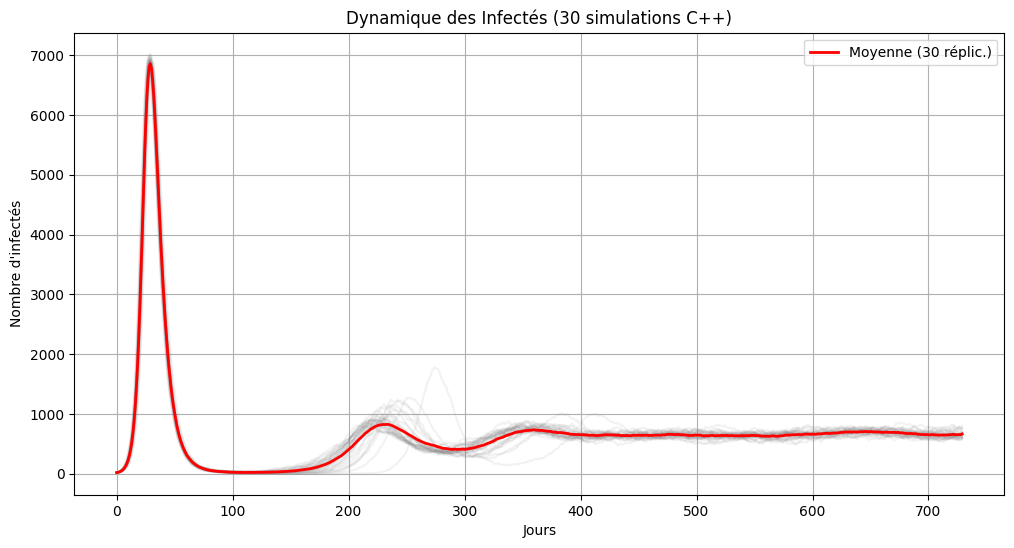

--- Statistiques sur le 1er Pic (30 réplications) ---
Hauteur moyenne du pic : 6904.30 individus
Écart-type hauteur : 64.13
Date moyenne du pic : Jour 28.8
Écart-type date : 0.86 jours


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

# 1. Lire tous les fichiers CSV générés par le C++
fichiers = glob.glob("resultats_sma_cpp_*.csv")
fichiers.sort() # Pour avoir l'ordre 1, 10, 11... (pas grave pour la moyenne)

print(f"Nombre de fichiers trouvés : {len(fichiers)}")

# On va stocker les courbes de Infectés (I) pour chaque réplication
tous_les_I = []

plt.figure(figsize=(12, 6))

# 2. Boucle de lecture
for f in fichiers:
    df = pd.read_csv(f)
    tous_les_I.append(df['I'].values)

    # On trace chaque courbe en gris clair (spaghetti plot)
    plt.plot(df['jour'], df['I'], color='gray', alpha=0.1)

# Transformation en tableau numpy pour calculs faciles
tous_les_I = np.array(tous_les_I)
# Forme : (30 réplications, 730 jours)

# 3. Calcul de la MOYENNE jour par jour
moyenne_I = np.mean(tous_les_I, axis=0)

# On trace la moyenne en rouge épais
plt.plot(df['jour'], moyenne_I, color='red', linewidth=2, label='Moyenne (30 réplic.)')

plt.title("Dynamique des Infectés (30 simulations C++)")
plt.xlabel("Jours")
plt.ylabel("Nombre d'infectés")
plt.legend()
plt.grid(True)
plt.show()

# 4. Analyse statistique des PICS (Hauteur et Date)
pics_hauteur = []
pics_date = []

for i in range(len(fichiers)):
    courbe = tous_les_I[i]
    hauteur = np.max(courbe)
    date = np.argmax(courbe) # Indice du max

    pics_hauteur.append(hauteur)
    pics_date.append(date)

# Affichage des stats
print(f"--- Statistiques sur le 1er Pic (30 réplications) ---")
print(f"Hauteur moyenne du pic : {np.mean(pics_hauteur):.2f} individus")
print(f"Écart-type hauteur : {np.std(pics_hauteur):.2f}")
print(f"Date moyenne du pic : Jour {np.mean(pics_date):.1f}")
print(f"Écart-type date : {np.std(pics_date):.2f} jours")


In [ ]:
%%writefile sma_seirs.c
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>

#define TAILLE_GRILLE 300
#define NB_AGENTS 20000
#define DUREE 730
#define BETA 0.5

#define MOY_DE 3.0
#define MOY_DI 7.0
#define MOY_DR 365.0

// Etats
#define S 0
#define E 1
#define I 2
#define R 3

typedef struct {
    int id;
    int x, y;
    int statut;
    int temps_dans_etat;
    int dE, dI, dR;
} Agent;

// Variables globales pour le PRNG simple (rand standard)
// Note: En HPC on utiliserait mieux, mais rand() suffit pour l'exercice C
// Fonctions utilitaires
int tirage_exponentiel(double moyenne) {
    double r = (double)rand() / (double)RAND_MAX;
    // Eviter log(0)
    if(r >= 1.0) r = 0.999999;
    return (int)round(-moyenne * log(1.0 - r));
}

int main(int argc, char* argv[]) {
    // Graine
    int graine = 42;
    if (argc > 1) graine = atoi(argv[1]);
    srand(graine);

    printf("Simulation SMA en C (Graine: %d)\n", graine);
    clock_t debut = clock();

    // 1. Allocations
    Agent* population = (Agent*)malloc(NB_AGENTS * sizeof(Agent));

    // Grille : tableau de pointeurs vers listes chainées ou simple tableau max ?
    // Pour faire simple en C sans std::vector, on va juste scanner les agents à chaque fois
    // ou faire une grille statique avec un max d'agents par case (ex: 50).
    // MÉTHODE OPTIMISÉE C : Liste chaînée par case
    // head[case] = index du premier agent, next[agent] = index du suivant
    static int head[TAILLE_GRILLE * TAILLE_GRILLE];
    static int next_agent[NB_AGENTS];

    // Init population
    for(int i=0; i<NB_AGENTS; ++i) {
        population[i].id = i;
        population[i].x = rand() % TAILLE_GRILLE;
        population[i].y = rand() % TAILLE_GRILLE;
        population[i].statut = S;
        population[i].temps_dans_etat = 0;
        population[i].dE = tirage_exponentiel(MOY_DE);
        population[i].dI = tirage_exponentiel(MOY_DI);
        population[i].dR = tirage_exponentiel(MOY_DR);
    }

    // Infecter 20 premiers
    for(int i=0; i<20; ++i) population[i].statut = I;

    // Fichier CSV
    char nom_fichier[50];
    sprintf(nom_fichier, "resultats_sma_c_%d.csv", graine);
    FILE* f = fopen(nom_fichier, "w");
    fprintf(f, "jour,S,E,I,R\n");

    // --- Boucle Temps ---
    for(int jour=0; jour<DUREE; ++jour) {

        // A. Reset Grille (table de hachage spatiale)
        for(int k=0; k<TAILLE_GRILLE*TAILLE_GRILLE; ++k) head[k] = -1;

        // B. Déplacement et Enregistrement
        for(int i=0; i<NB_AGENTS; ++i) {
            population[i].x = rand() % TAILLE_GRILLE;
            population[i].y = rand() % TAILLE_GRILLE;

            int idx_case = population[i].x * TAILLE_GRILLE + population[i].y;

            // Insertion en tête de liste chainée
            next_agent[i] = head[idx_case];
            head[idx_case] = i;
        }

        // C. Infection & Transitions
        // On mélange l'ordre en C ? Complexe sans bibliothèque.
        // On fait itération simple pour l'exercice C "à la main".
        // (L'énoncé demande de coder le modèle, l'asynchronisme parfait est dur en pur C simple)

        int nb_S=0, nb_E=0, nb_I=0, nb_R=0;

        for(int i=0; i<NB_AGENTS; ++i) {
            Agent* ag = &population[i];

            // Infection
            if(ag->statut == S) {
                int n_infectes = 0;

                // Voisinage Moore
                for(int dx=-1; dx<=1; ++dx) {
                    for(int dy=-1; dy<=1; ++dy) {
                         int vx = (ag->x + dx + TAILLE_GRILLE) % TAILLE_GRILLE;
                         int vy = (ag->y + dy + TAILLE_GRILLE) % TAILLE_GRILLE;
                         int idx_voisin = vx * TAILLE_GRILLE + vy;

                         // Parcourir la liste chainée de la case voisine
                         int curr = head[idx_voisin];
                         while(curr != -1) {
                             if(population[curr].statut == I) {
                                 n_infectes++;
                             }
                             curr = next_agent[curr];
                         }
                    }
                }

                if(n_infectes > 0) {
                    double p = 1.0 - exp(-0.5 * n_infectes);
                    double alea = (double)rand()/RAND_MAX;
                    if(alea < p) {
                        ag->statut = E;
                        ag->temps_dans_etat = 0;
                    }
                }
            }
            // Transitions
            else if(ag->statut == E) {
                if(ag->temps_dans_etat >= ag->dE) { ag->statut = I; ag->temps_dans_etat=0; }
            }
            else if(ag->statut == I) {
                if(ag->temps_dans_etat >= ag->dI) { ag->statut = R; ag->temps_dans_etat=0; }
            }
            else if(ag->statut == R) {
                if(ag->temps_dans_etat >= ag->dR) { ag->statut = S; ag->temps_dans_etat=0; }
            }

            ag->temps_dans_etat++;

            if(ag->statut == S) nb_S++;
            else if(ag->statut == E) nb_E++;
            else if(ag->statut == I) nb_I++;
            else if(ag->statut == R) nb_R++;
        }

        fprintf(f, "%d,%d,%d,%d,%d\n", jour, nb_S, nb_E, nb_I, nb_R);
    }

    fclose(f);
    free(population);

    clock_t fin = clock();
    double temps_cpu = (double)(fin - debut) / CLOCKS_PER_SEC;
    printf("Termine en %.4f s.\n", temps_cpu);

    return 0;
}


Writing sma_seirs.c


In [ ]:
!gcc -O3 sma_seirs.c -o sma_c -lm
!./sma_c 1


Simulation SMA en C (Graine: 1)
Termine en 0.9328 s.


In [ ]:
%%writefile sma_seirs.c
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>

// Paramètres
#define TAILLE_GRILLE 300
#define NB_AGENTS 20000
#define DUREE 730
#define BETA 0.5

// Moyennes
#define MOY_DE 3.0
#define MOY_DI 7.0
#define MOY_DR 365.0

// États
enum { S=0, E=1, I=2, R=3 };

typedef struct {
    int id;
    int x, y;
    int statut;
    int temps_dans_etat;
    int dE, dI, dR;
} Agent;

// Grille : tableau de tableaux dynamiques (listes chainées simplifiées ou réallocation)
// Pour faire simple en C, on va utiliser une structure de liste chaînée pour la grille
typedef struct Node {
    int id_agent;
    struct Node* next;
} Node;

Node* grille[TAILLE_GRILLE * TAILLE_GRILLE];

// Tirage loi exponentielle
int tirage_expo(double moy) {
    double r = (double)rand() / (double)RAND_MAX;
    if(r >= 1.0) r = 0.999999;
    return (int)round(-moy * log(1.0 - r));
}

// Ajouter un agent dans la grille
void ajouter_grille(int idx, int x, int y) {
    int pos = x * TAILLE_GRILLE + y;
    Node* nouveau = (Node*)malloc(sizeof(Node));
    nouveau->id_agent = idx;
    nouveau->next = grille[pos];
    grille[pos] = nouveau;
}

// Vider la grille
void vider_grille() {
    for(int i=0; i<TAILLE_GRILLE*TAILLE_GRILLE; i++) {
        Node* cour = grille[i];
        while(cour != NULL) {
            Node* tmp = cour;
            cour = cour->next;
            free(tmp);
        }
        grille[i] = NULL;
    }
}

int main(int argc, char* argv[]) {
    srand(time(NULL));
    if(argc > 1) srand(atoi(argv[1]));

    printf("Simulation SMA en C standard...\n");

    // Allocation des agents
    Agent* population = (Agent*)malloc(NB_AGENTS * sizeof(Agent));

    // Initialisation
    for(int i=0; i<NB_AGENTS; i++) {
        population[i].id = i;
        population[i].x = rand() % TAILLE_GRILLE;
        population[i].y = rand() % TAILLE_GRILLE;
        population[i].statut = S;
        population[i].temps_dans_etat = 0;
        population[i].dE = tirage_expo(MOY_DE);
        population[i].dI = tirage_expo(MOY_DI);
        population[i].dR = tirage_expo(MOY_DR);
    }

    // Infecter 20 agents
    for(int k=0; k<20; k++) {
        int idx = rand() % NB_AGENTS;
        population[idx].statut = I;
    }

    FILE* f = fopen("resultats_sma_c.csv", "w");
    fprintf(f, "jour,S,E,I,R\n");

    // Simulation
    for(int jour=0; jour<DUREE; jour++) {
        // 1. Déplacement et mise en grille
        vider_grille();
        for(int i=0; i<NB_AGENTS; i++) {
            population[i].x = rand() % TAILLE_GRILLE;
            population[i].y = rand() % TAILLE_GRILLE;
            ajouter_grille(i, population[i].x, population[i].y);
        }

        int nbS=0, nbE=0, nbI=0, nbR=0;

        // 2. Dynamique
        for(int i=0; i<NB_AGENTS; i++) {
            // Infection
            if(population[i].statut == S) {
                int n_infectes = 0;
                for(int dx=-1; dx<=1; dx++) {
                    for(int dy=-1; dy<=1; dy++) {
                        int vx = (population[i].x + dx + TAILLE_GRILLE) % TAILLE_GRILLE;
                        int vy = (population[i].y + dy + TAILLE_GRILLE) % TAILLE_GRILLE;
                        int pos = vx * TAILLE_GRILLE + vy;

                        Node* cour = grille[pos];
                        while(cour != NULL) {
                            if(population[cour->id_agent].statut == I) n_infectes++;
                            cour = cour->next;
                        }
                    }
                }
                if(n_infectes > 0) {
                    double p = 1.0 - exp(-0.5 * n_infectes);
                    double r = (double)rand() / RAND_MAX;
                    if(r < p) {
                        population[i].statut = E;
                        population[i].temps_dans_etat = 0;
                    }
                }
            }
            // Transitions
            else if(population[i].statut == E) {
                if(population[i].temps_dans_etat >= population[i].dE) { population[i].statut=I; population[i].temps_dans_etat=0; }
            }
            else if(population[i].statut == I) {
                if(population[i].temps_dans_etat >= population[i].dI) { population[i].statut=R; population[i].temps_dans_etat=0; }
            }
            else if(population[i].statut == R) {
                if(population[i].temps_dans_etat >= population[i].dR) { population[i].statut=S; population[i].temps_dans_etat=0; }
            }

            population[i].temps_dans_etat++;

            if(population[i].statut == S) nbS++;
            else if(population[i].statut == E) nbE++;
            else if(population[i].statut == I) nbI++;
            else nbR++;
        }
        fprintf(f, "%d,%d,%d,%d,%d\n", jour, nbS, nbE, nbI, nbR);
    }

    fclose(f);
    free(population);
    vider_grille(); // Nettoyage final
    printf("Simulation C terminée.\n");
    return 0;
}


Writing sma_seirs.c


In [ ]:
%%bash
gcc -O3 sma_seirs.c -o sma_c -lm
./sma_c


Simulation SMA en C standard...
Simulation C terminée.


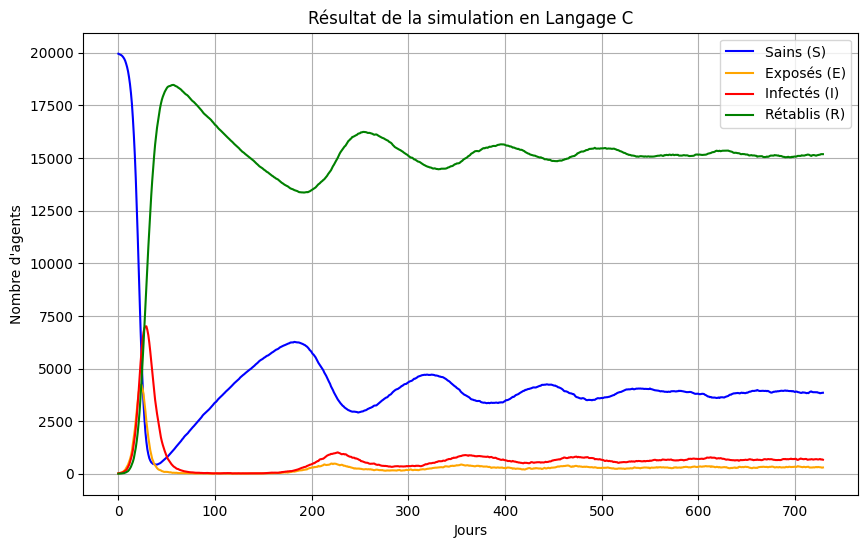

Pic épidémique atteint : 7005 personnes infectées simultanément.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. On lit le fichier créé par le code C
data_c = pd.read_csv("resultats_sma_c.csv")

# 2. On trace les courbes
plt.figure(figsize=(10, 6))
plt.plot(data_c['jour'], data_c['S'], label='Sains (S)', color='blue')
plt.plot(data_c['jour'], data_c['E'], label='Exposés (E)', color='orange')
plt.plot(data_c['jour'], data_c['I'], label='Infectés (I)', color='red')
plt.plot(data_c['jour'], data_c['R'], label='Rétablis (R)', color='green')

plt.title("Résultat de la simulation en Langage C")
plt.xlabel("Jours")
plt.ylabel("Nombre d'agents")
plt.legend()
plt.grid(True)
plt.show()

# 3. Petit résumé chiffré
pic_max = data_c['I'].max()
print(f"Pic épidémique atteint : {pic_max} personnes infectées simultanément.")
